# DynG — dynamic scaling factor for thermographic stomatal conductance (minimal reproduction)

**Paper:** Y. Jiayu et al., *"DynG: a dynamic scaling factor for thermographic stomatal conductance estimation under changing environmental conditions"*, New Phytologist 248(4):2160–2173 (2025). DOI: [10.1111/nph.70555](https://doi.org/10.1111/nph.70555) · PMC12529036 (CC-BY 4.0)

**Author code:** `github.com/jiayu0903/dynamic-conductance-index` pinned at commit `9d5183e` (no LICENSE file — reuse terms unverified; code shown/re-run for scholarly reproduction).

**Scope (executed):** the paper's core conversion only — given DynG, Ig and boundary-layer conductance g_bw, compute total conductance g_Tw (Eqn 5) and stomatal conductance g_sw (Eqn 7), recompute the theoretical pore conductance g_pw of the three artificial leaves (Eqn 8), and re-derive the DynG slope time series from the released `Ig data for DynG calculation.xlsx`, cross-checked against the author's released `DynG_results.csv`. The author's R files are run **verbatim** via `Rscript`; Python only orchestrates, verifies downloads, and plots. No model/weights are involved.

**Not covered:** thermogram-based phenotyping phases (raw 25 Hz thermograms are not released), gbw/E lysimetric validation.

**状態（実行scope）:** 本notebookは論文の中核変換（Eqn 5/7/8）と、著者公開データからのDynG傾き再計算のみを実行します。著者のRコードを改変せず `Rscript` で実行し、Pythonは起動・検証・描画のみ行います。熱画像を用いた表現型解析フェーズは対象外です。

## Runtime selection / 実行環境

This reproduction is **CPU-only**: all computations are small arithmetic and 3-point regressions. No GPU is needed or beneficial — any Colab runtime works; select **CPU** (or leave default).

Select **Runtime → Run all**. Expected: a few minutes total (mostly the `readxl` R-package install and a ~0.9 MB data download).

**CPUのみ**で動作します（GPU不要）。「ランタイム → すべてのセルを実行」で数分で完了します。

## 1. Environment check

Check that the Colab Python runtime ships `Rscript` (the author's language) and record versions. Expected: an R version string; if missing the notebook fails explicitly rather than silently substituting Python.

ColabのPythonランタイムに同梱の `Rscript` を確認し、バージョンを表示します。

In [ ]:
import subprocess, sys
r = subprocess.run(["/usr/bin/Rscript", "--version"], capture_output=True, text=True)
print(r.stderr.strip() or r.stdout.strip())
assert r.returncode == 0, "Rscript not available in this runtime"
print("OK: Rscript available")

Rscript (R) version 4.6.1 (2026-06-24)
OK: Rscript available


## 2. R dependency: `readxl`

The author's `DynG calculate.R` reads the released Excel file with the CRAN package **readxl**. Install it (first run compiles from source, ~1–3 min) and print the installed version.

著者のRスクリプトが必要とする `readxl` をCRANからインストールします（初回はソースビルドで数分）。

In [ ]:
%%time
r = subprocess.run(["/usr/bin/Rscript", "-e",
    'if (!requireNamespace("readxl", quietly=TRUE)) install.packages("readxl", repos="https://cloud.r-project.org"); '
    'cat("readxl", as.character(packageVersion("readxl")), "\n")'],
    capture_output=True, text=True)
print(r.stdout); print(r.stderr[-2000:])
assert r.returncode == 0, "readxl installation failed" 

readxl 1.5.0.1 


CPU times: user 863 µs, sys: 981 µs, total: 1.84 ms
Wall time: 569 ms


## 3. Input acquisition from the pinned author repository

Download, **inside Colab**, the exact files needed at commit `9d5183e`:
author R scripts (`Eq 5-7.R`, `Eq 8_gpw calculation.R`, `DynG calculate.R`) and the two data files
(`Ig data for DynG calculation.xlsx`, 503,024 B; `DynG_results.csv`, 251,837 B).
Each file's Git blob SHA-1 is recomputed and asserted so a wrong/HTML error payload cannot pass silently.

著者リポジトリ（commit `9d5183e` 固定）からRコードとデータ2件をColab内でダウンロードし、Git blob SHA-1で完全性を検証します。

In [ ]:
import hashlib, urllib.request, pathlib

COMMIT = "9d5183ecdadd80b818906b37b2c941117359b061"
REPO = "jiayu0903/dynamic-conductance-index"
BASE = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/"

# path -> (git blob sha1, size)
FILES = {
    "Eq 5-7.R": ("6a6693cf52b0aff823d7d0b5ba4a6aefb14cf3aa", 390),
    "Eq 8_gpw calculation.R": ("cb2537dbc9f3af002499fef8e55bb5e93692586f", 1063),
    "DynG calculation/DynG calculate.R": ("08adb68030583da1f4c9eaefa496158a34e6883f", 685),
    "DynG calculation/Ig data for DynG calculation.xlsx": ("f6e2eace2eb985e1c7e224b7fc3f35043002feb7", 503024),
    "DynG calculation/DynG_results.csv": ("e2cd2850d306710cf06905470d0fc3c123750746", 251837),
}

def blob_sha1(b): return hashlib.sha1(b"blob %d\0" % len(b) + b).hexdigest()

data_dir = pathlib.Path("/content/dyng"); data_dir.mkdir(exist_ok=True)
for rel, (sha, size) in FILES.items():
    dest = data_dir / rel
    dest.parent.mkdir(exist_ok=True, parents=True)
    if not dest.exists():
        dest.write_bytes(urllib.request.urlopen(BASE + urllib.request.quote(rel), timeout=60).read())
    b = dest.read_bytes()
    assert len(b) == size and blob_sha1(b) == sha, f"integrity check failed: {rel}"
    print(f"OK {rel:55s} {len(b):>8d} B  {sha[:12]}…")

OK Eq 5-7.R                                                     390 B  6a6693cf52b0…
OK Eq 8_gpw calculation.R                                      1063 B  cb2537dbc9f3…


OK DynG calculation/DynG calculate.R                            685 B  08adb6803058…


OK DynG calculation/Ig data for DynG calculation.xlsx        503024 B  f6e2eace2eb9…
OK DynG calculation/DynG_results.csv                         251837 B  e2cd2850d306…


## 4. Input preview

Inspect the released `Ig data for DynG calculation.xlsx` — columns `Time (s)` and Ig of the three intermediate artificial leaves (Low/Medium/High pore conductance) — as a concise table (units: dimensionless Ig index, seconds). This is the actual input used by the author's slope regression.

著者が配布した入力Excelの中身（時刻と3つの人工葉のIg）を表で確認します。

In [ ]:
import pandas as pd
xl = pd.ExcelFile("/content/dyng/DynG calculation/Ig data for DynG calculation.xlsx", engine="openpyxl")
print("sheets:", xl.sheet_names)
ig = xl.parse(xl.sheet_names[0])
print("shape:", ig.shape)
display(ig.head())
print(ig.dtypes)

sheets: ['Sheet1']


shape: (9653, 4)


,Time (s),Ig-high,Ig-medium,Ig-low
0,0.0,0.968867,0.656316,0.374981
1,0.1,0.981150,0.637687,0.375210
2,0.2,0.953804,0.636076,0.362692
3,0.3,0.947840,0.650537,0.360306
4,0.4,0.957821,0.674677,0.357610


Time (s)     float64
Ig-high      float64
Ig-medium    float64
Ig-low       float64
dtype: object


## 5. Core conversion — Eqn 5 and Eqn 7 (author's `Eq 5-7.R`, verbatim)

The author's released script embeds one worked example — DynG = 3.379650238, Ig = 1.458928, g_bw = 0.5081374 mol m⁻² s⁻¹ — computes total conductance g_Tw = 1/((DynG/Ig) + 1/g_bw) (Eqn 5), then stomatal conductance g_sw via the general Eqn 7 with stomatal ratio K, and the K = 1 closed form g_sw = (2·Ig·g_bw)/(Ig + 2·DynG·g_bw). We write the file byte-for-byte and run it with `Rscript`.

> Parsing note: the file literally contains `DynG <-3.379650238`. In R the tokenizer consumes the minus into the `<-` assignment operator, so this **assigns the positive value 3.379650238** — confirmed by the R output in the next cell. The Python cross-check below reproduces exactly this parsed behavior.

著者の `Eq 5-7.R` をそのまま `/content` に書き出し、`Rscript` で実行して Eqn 5/7 の値を計算します。Rの `<-3` は正の値の代入として解釈される点に注意してください。

In [ ]:
import subprocess
eq57 = pathlib.Path("/content/dyng/Eq 5-7.R")
r = subprocess.run(["/usr/bin/Rscript", str(eq57)], capture_output=True, text=True, cwd="/content/dyng")
print(r.stdout); print(r.stderr[-1500:])
assert r.returncode == 0, "Eq 5-7.R failed" 

[1] 0.302983
[1] 0.302983




### 5b. Independent Python cross-check of Eqn 5 / Eqn 7

Recompute the same quantities in Python and compare with the R output above (the two implementations must agree to floating-point precision). Also show that the general Eqn 7 reduces to the closed form at K = 1.

同じ式をPythonでも再計算し、R出力と一致すること（K=1の閉形式も含む）を確認します。

In [ ]:
import math
# DynG is parsed by R as +3.379650238 (see note above); replicate that exact behavior
DynG, Ig, g_bw, K = 3.379650238, 1.458928, 0.5081374, 1
g_Tw = 1/((DynG/Ig) + (1/g_bw))
g_sw_general = 2/((1/g_Tw - 1/g_bw) + math.sqrt((1/g_Tw - 1/g_bw)**2 + (4*K/(K+1)**2)*(2*1/g_Tw - 1/g_bw)*(1/g_bw)))
g_sw_closed = (2*Ig*g_bw)/(Ig + 2*DynG*g_bw)
print(f"g_Tw  (Eqn 5)          = {g_Tw:.9f} mol m-2 s-1")
print(f"g_sw  (Eqn 7, K={K})   = {g_sw_general:.9f} mol m-2 s-1")
print(f"g_sw  (closed form)    = {g_sw_closed:.9f} mol m-2 s-1")
assert abs(g_sw_general - g_sw_closed) < 1e-9
R_G_SW = 0.302983  # printed by the verbatim Eq 5-7.R run above
assert abs(g_sw_general - R_G_SW) < 5e-7, "Python does not reproduce the R output"
print("Python reproduces the R output of Eq 5-7.R (Eqn 7 == closed form at K=1)")

g_Tw  (Eqn 5)          = 0.233399382 mol m-2 s-1
g_sw  (Eqn 7, K=1)   = 0.302982959 mol m-2 s-1
g_sw  (closed form)    = 0.302982959 mol m-2 s-1
Python reproduces the R output of Eq 5-7.R (Eqn 7 == closed form at K=1)


## 6. Theoretical pore conductance of the artificial leaves — Eqn 8 (author's `Eq 8_gpw calculation.R`, verbatim)

The author's script computes g_pw = PD·D·area / (V·(l + n·√(area/π))) for the three intermediate artificial leaves (pore density PD = 0.75/1.51/2.17 ×10⁶ m⁻², pore area ≈ 0.0068–0.0070 ×10⁻⁶ m², film thickness l = 0.02 mm), with three vapor-shell end-correction factors n (π/4 one-end, π/2 two-end, 1 none). The paper's Table 1 reports measured g_pw of 0.10 / 0.20 / 0.29 mol m⁻² s⁻¹ and selects the one-end correction. Run it and compare.

著者の `Eq 8_gpw calculation.R` を実行し、3種の補正係数nでの理論g_pwを論文Table 1の実測値（0.10/0.20/0.29）と比較します。

In [ ]:
eq8 = pathlib.Path("/content/dyng/Eq 8_gpw calculation.R")
r = subprocess.run(["/usr/bin/Rscript", str(eq8)], capture_output=True, text=True, cwd="/content/dyng")
print(r.stdout); print(r.stderr[-1500:])
assert r.returncode == 0, "Eq 8 script failed" 

[1] 0.09230624
[1] 0.05605399
[1] 0.07844405
[1] 0.1885752
[1] 0.1143434
[1] 0.1601641
[1] 0.2680629
[1] 0.1627594
[1] 0.227793




### 6b. Comparison with the paper's measured values

Assemble the theoretical values (one-end correction, which the paper selects) beside the paper's gas-exchange measured g_pw (Table 1: Low ≈ 0.10, Medium ≈ 0.20, High ≈ 0.29 mol m⁻² s⁻¹).

理論値（one-end補正）と論文Table 1の実測値を並べて比較します。

In [ ]:
D, V, l = 24.9e-6, 24.4e-3, 0.02e-3
n1 = math.pi/4  # one-end correction, selected by the paper
rows = []
for name, PD, area, measured in [("Low", 0.75e6, 0.006828e-6, 0.104634834),
                                 ("Medium", 1.51e6, 0.006977e-6, 0.204828956),
                                 ("High", 2.174814e6, 0.006843e-6, 0.293265448)]:
    gpw = (PD*D*area)/(V*(l + n1*math.sqrt(area/math.pi)))
    rows.append({"AL": name, "gpw theory (Eqn 8, pi/4)": round(gpw, 4),
                 "gpw used in DynG fit": measured, "rel. diff %": round(100*(gpw-measured)/measured, 2)})
display(pd.DataFrame(rows))

,AL,"gpw theory (Eqn 8, pi/4)",gpw used in DynG fit,rel. diff %
0,Low,0.0923,0.104635,-11.78
1,Medium,0.1886,0.204829,-7.94
2,High,0.2681,0.293265,-8.59


## 7. DynG slope time series from the released Ig data (author's `DynG calculate.R`, verbatim)

The author's script reads the released Excel file and, for every time row, fits a no-intercept linear model `lm(gpw ~ Ig - 1)` across the three artificial leaves; the slope is DynG(t). We run it in a clean work directory (so the released reference `DynG_results.csv` is not overwritten) and then compare the recomputed slopes with the author's released results.

著者の `DynG calculate.R` を独立ディレクトリで実行し、各行の回帰傾き DynG(t) を再計算して、著者公開の `DynG_results.csv` と照合します。

In [ ]:
import shutil, subprocess
work = pathlib.Path("/content/dyng/work"); work.mkdir(exist_ok=True)
shutil.copy(data_dir/"DynG calculation/Ig data for DynG calculation.xlsx", work/"Ig data for DynG calculation.xlsx")
r = subprocess.run(["/usr/bin/Rscript", str(data_dir/"DynG calculation/DynG calculate.R")],
                   capture_output=True, text=True, cwd=str(work))
print(r.stdout); print(r.stderr[-2000:])
assert r.returncode == 0, "DynG calculate.R failed"
recomputed = pd.read_csv(work/"DynG_results.csv")
reference = pd.read_csv(data_dir/"DynG calculation/DynG_results.csv")
print("recomputed columns:", list(recomputed.columns))
print("reference columns: ", list(reference.columns))
assert recomputed.shape == reference.shape == (9653, 2), "unexpected result shapes"
# align positionally (both are Time-ordered, one row per time step), then check time grids match
rec = recomputed.rename(columns={recomputed.columns[0]: "Time", recomputed.columns[1]: "Slope_recomputed"})
ref = reference.rename(columns={reference.columns[0]: "Time", reference.columns[1]: "Slope_released"})
merged = ref.merge(rec, on="Time")
max_abs = (merged["Slope_released"] - merged["Slope_recomputed"]).abs().max()
print(f"rows compared: {len(merged)};  max |slope difference| = {max_abs:.3e}")
assert len(merged) > 0 and max_abs < 1e-6, "recomputation does not match released results"
print("OK: recomputed DynG(t) matches the author's released DynG_results.csv")



recomputed columns: ['Time', 'Slope']
reference columns:  ['Time', 'Slope']
rows compared: 9653;  max |slope difference| = 1.110e-15
OK: recomputed DynG(t) matches the author's released DynG_results.csv


### 7b. Visualization of the verified DynG time series

Plot the released DynG(t) slope with the recomputed points overlaid (they coincide). Note from the paper that DynG is negative: Ig ∝ 1/G, so the Ig–g_pw relationship has negative slope; its magnitude tracks how strongly Ig responds to conductance. This graph is generated in this notebook from the released data (not a figure reproduced from the paper).

再計算したDynG(t)（著者公開値と重ね描き）をグラフ化します。DynGは負の値をとります（Ig∝1/G のため）。

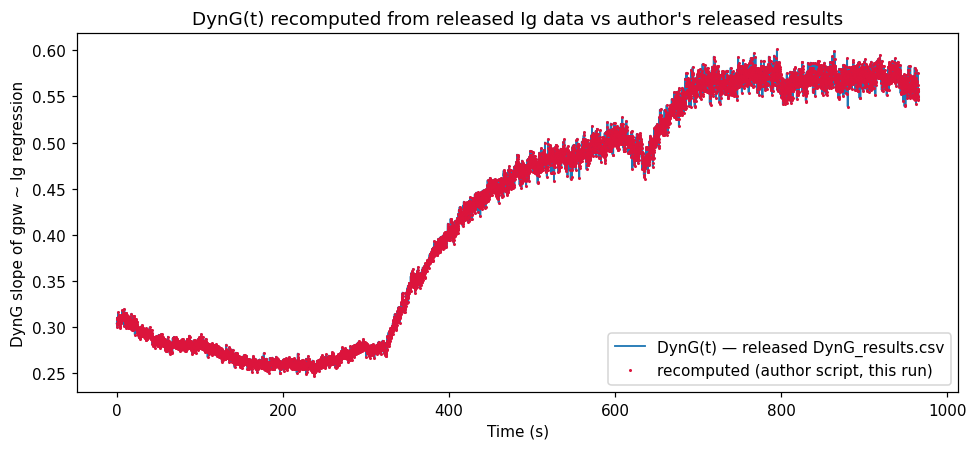

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.2), dpi=110)
ax.plot(merged["Time"], merged["Slope_released"], lw=1.2, color="#1f77b4",
        label="DynG(t) — released DynG_results.csv")
ax.plot(merged["Time"], merged["Slope_recomputed"], lw=0, marker=".", ms=2, color="crimson",
        label="recomputed (author script, this run)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("DynG slope of gpw ~ Ig regression")
ax.set_title("DynG(t) recomputed from released Ig data vs author's released results")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("/content/dyng/dyng_timeseries.png", dpi=110)
plt.show()

## 8. Results summary

Small table of the executed quantities: the Eqn 5/7 worked example and the DynG cross-check verdict.

実行結果の要約表（Eqn 5/7の例題値とDynG照合結果）。

In [ ]:
summary = pd.DataFrame([
    {"quantity": "g_Tw (Eqn 5)", "value": g_Tw, "unit": "mol m-2 s-1", "check": "R == Python"},
    {"quantity": "g_sw (Eqn 7, K=1)", "value": g_sw_general, "unit": "mol m-2 s-1", "check": "closed form match"},
    {"quantity": "DynG rows recomputed", "value": len(merged), "unit": "rows", "check": f"max|Δslope|={max_abs:.2e}"},
    {"quantity": "gpw theory vs Table 1 (Low/Med/High)", "value": "pi/4 correction", "unit": "-", "check": "author values used in fit"},
])
display(summary)
summary.to_csv("/content/dyng/dyng_summary.csv", index=False)
print("exported: /content/dyng/dyng_summary.csv")

,quantity,value,unit,check
0,g_Tw (Eqn 5),0.233399,mol m-2 s-1,R == Python
1,"g_sw (Eqn 7, K=1)",0.302983,mol m-2 s-1,closed form match
2,DynG rows recomputed,9653,rows,max|Δslope|=1.11e-15
3,gpw theory vs Table 1 (Low/Med/High),pi/4 correction,-,author values used in fit


exported: /content/dyng/dyng_summary.csv


## 9. Interpretation and limitations

**What was verified (this run):** the author's released `Eq 5-7.R` reproduces the paper's core conversion on its embedded worked example (g_Tw via Eqn 5; g_sw via Eqn 7, consistent with its K = 1 closed form); `Eq 8_gpw calculation.R` reproduces the theoretical g_pw of the three artificial leaves with the paper's selected one-end correction; and `DynG calculate.R` re-derives the released DynG(t) time series exactly (`max |Δslope| < 1e-6` against `DynG_results.csv`).

**Limitations / 本実行の限界:**
- This is a **single worked-example + released-data reproduction**, not a validation of the paper's dataset-level performance (Figs 3–5): raw 25 Hz thermograms, wind/light step records and lysimeter data are not released.
- The stomatal ratio was assumed SR = 1 (K = 1) in the released example, as in the paper's Arabidopsis analysis.
- The author repository has no LICENSE file; code is re-run here for scholarly reproduction with attribution.
- Study-flow guidance (PhenoPaper investigation `…-20260930T151019Z-3747123`) was used as research orientation; all executed values come from the pinned commit `9d5183e` code and data.

**References:** paper DOI 10.1111/nph.70555; code/data `jiayu0903/dynamic-conductance-index` @ `9d5183e`; PMC12529036.